# Spatial and Temporal Transfer of models

# Introduction

Oftentimes, we have training data (field data or data collected from visual interpretation) from a specific time period or specific place and we can use it to train a classification (or regression) model for that time or place with good results.  

We also often have similar imagery available for other locations or time periods (e.g. if we are creating a map using a Landsat-8 image of Ottawa in summer 2023, we also have Landsat-8 images for Ottawa in other years, and we also have Landsat-8 images available for other locations that have the same classes).

In these cases, it might be tempting to build a model to map specific classes for one location (or one time period) and simply apply that same model to a new area (or time period) without re-training with new training data.  

In some cases, this works well and in others it doesn't.  It only works well when the training sample from the original location/time is representative of and captures the variability in the other location/time. However, this often isn't true, for example when there are differences in the conditions on the ground between two locations/times (e.g. after a rain event vs during a drought), differences in the the biophysical characteristics of the class over space or time (e.g. peatlands look different in the east and west; images acquired at different times during the phenological cycle), when there are differences in sensors (e.g. sensor drift over time, atmospheric conditions etc).  

In this lab we are going to talk through examples transfering data over time and over space.  In both cases, we are going to perform an image classification and then "transfer" it to another location/time without retraining the model.  

In [1]:
!pip install google.colab

ERROR: Could not find a version that satisfies the requirement google.colab (from versions: none)
ERROR: No matching distribution found for google.colab


In [162]:
# Let's setup our script first
# Install geemap and geopandas
#!pip install geemap
!pip install geopandas
!pip install pyCRS

# Import the necessary libraries
import pycrs
import ee
import numpy as np
import geemap as geemap
import json

import geopandas as geopandas
import pandas as pd

import plotnine
from plotnine import *
import matplotlib.pyplot as plt

In [3]:
# Authenticate and initialize this instance of GEE in Google Colab
# Follow the prompts and fill in authentication code
ee.Authenticate()
ee.Initialize(project='ee-cptcitrus-main')

## Definition of functions

We have a cloud mask function and a quality bands function, which we've seen in other labs. This time we're using the quality bands function to add a band for NDVI.

Below that we have Tasseled Cap brightness, greenness, and wetness functions.

The Tasseled Cap transformation is based on the knowledge that as crops develop NIR EMR increases and red reflectance decreases (due to increasing vegetation cover over soil). The purpose is to simplify analysis of changes to vegetated areas using remote sensing.

*insert photo here*

The function we've defined below reduces the spectral information from several multispectral bands down to three primary components which contain over 90% of the important spectral information:

*   Brightness (weighted sum of reflectance in all bands)
*   Greenness (focus on B4 NIR and B5 SWIR)
*   Wetness (focus on B2 Green, B3 Red, and B4 NIR)

Brightness helps with the interpretation of exposed rock and soil.

Greenness can be interpreted as the lushness and health of vegetation.

Wetness represents soil moisture, water bodies, and inundated areas.

The band math involves B1-B5 and B7. Band 6 is a thermal infrared band with a different spatial resolution than the others, so we will skip it.

The functions will generate one Brightness, Greenness, and Wetness value per pixel, based on the spectral information in B1-B5 and B7 and this information will be contained in the new bands we created for each. You will see this when you look at our training data when we extract it.


In [4]:
# Define cloud masking function

def cloudMaskL5(image):
  # Bits 3 and 5 are cloud shadow and cloud, respectively.
  cloudShadowBitMask = 1 << 3 #select the cloud shadow bit location
  cloudsBitMask = 1 << 4 # select the cloud bit location
  # Get the pixel QA band.
  qa = image.select('QA_PIXEL')
  # Both flags should be set to zero, indicating clear conditions.
  # this only keeps pixels were both the cloud and cloud shadow bits are set to 0
  mask = qa.bitwiseAnd(cloudShadowBitMask).eq(0) \
      .And(qa.bitwiseAnd(cloudsBitMask).eq(0))
  # Return the masked image, not scaled to reflectance, with the QA bands.
  return image.updateMask(mask)

  # This function returns the cloudmasked images with an NDVI band added. The NDVI band will be used to determine the quality of a pixel - for Landsat5 (edit for other sensors)
def addQualityBands(l5image):
  return cloudMaskL5(l5image) \
                  .addBands(l5image.normalizedDifference(['SR_B4', 'SR_B3']).rename('ndvi')) \
                  .addBands(l5image.metadata('system:time_start'))

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# Tasseled Cap functions
# We're omitting B6 from our functions because for Landsat 5 TM Band 6 is thermal.
def tCapB(image):
  Brightness = image.expression(
      '((0.3029*B1)+(0.2786*B2)+(0.4733*B3)+(0.5599*B4)+(0.508*B5)+(0.1872*B7))',{
          'B1': image.select ('SR_B1').float(),
          'B2': image.select ('SR_B2').float(),
          'B3': image.select ('SR_B3').float(),
          'B4': image.select ('SR_B4').float(),
          'B5': image.select ('SR_B5').float(),
          'B7': image.select ('SR_B7').float(),
          }).rename('brightness');
  return image.addBands(Brightness);

def tCapG(image):
  Greeness = image.expression(
      '((-0.2941*B1)-(0.243*B2)-(0.5424*B3)+(0.7276*B4)+(0.0713 * B5)-(0.1608 * B7))',{
          'B1': image.select ('SR_B1').float(),
          'B2': image.select ('SR_B2').float(),
          'B3': image.select ('SR_B3').float(),
          'B4': image.select ('SR_B4').float(),
          'B5': image.select ('SR_B5').float(),
          'B7': image.select ('SR_B7').float(),
          }).rename('greeness');
  return image.addBands(Greeness);

def tCapW(image):
  Wetness = image.expression(
      '((0.1511*B1)+(0.1973*B2)+(0.3283*B3)+(0.3407*B4)-(0.7117 * B5)-(0.4559 * B7))',{
          'B1': image.select ('SR_B1').float(),
          'B2': image.select ('SR_B2').float(),
          'B3': image.select ('SR_B3').float(),
          'B4': image.select ('SR_B4').float(),
          'B5': image.select ('SR_B5').float(),
          'B7': image.select ('SR_B7').float(),
          }).rename('wetness');
  return image.addBands(Wetness);

In [7]:
# Applies scaling factors.
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B6').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )


## Load in imagery

We are going to use Alfred Bog as an example. We are going to make a cloud-free mosaic for Summer 1990 and add the tasseled-cap transformation parameters (greeness, brightness, wetness).   

In [8]:
# Create a point feature for our AOI (Alfred Bog)
point = ee.Geometry.Point([-74.8588,45.4839])

# Import the landsat-8 tier 1 surface reflectance as a variable
l5SR = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")


# Applies scaling factors.
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B6').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )


# Filter for images within our date range that overlap our point
# Sort by cloud cover and choose least cloudy (first)
l5SR_Summer1990 = l5SR.filterBounds(point) \
                      .filterDate('1990-06-01', '1990-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .qualityMosaic ('ndvi') \
                      .float()


################ NOTE the text says to choose the least cloudy, but here we choose the best NDVI pixel - QB

In [9]:
# Let's check out our cloud masked image on a map
Map = geemap.Map()

# Define the visparams for Landsat 5 (Red-B3, Green-B2, Blue-B1)
l5visparams = {
       'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
       'min': 0,
       'max': 0.3,
       'gamma': [0.95, 1.1, 1]
     }

Map.addLayer(l5SR_Summer1990, l5visparams,'l5SR_Summer1990')
Map.addLayer(point, {}, 'Alfred Bog')

Map.addLayerControl()
Map.centerObject(point,8)

Map

Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

# Training Data

First we need to grab our training data for the classification.

It is important to note that ALL classifications are only as good as your training data.

Koreen Millard has supplied some training data for Alfred Bog, which is for educational use only. For any other uses please contact her for permissions. This data has been made available to you. Download it and save it in an appropriate folder in your Google Drive.

In [10]:
# # Access our training data
# # Mounting your Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [120]:
# Import the training data and assign it to a variable
# Change this line to reflect the location in your drive
AlfredPts = 'C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2/TrainingDataAlfred/training_dataAlfred_v3.shp'
# For example: AlfredPts = '/content/drive/My Drive/Lab Data/training_dataAlfred.shp'

# Convert the shapefile (.shp) to an EE feature
shpdata = geemap.shp_to_ee(AlfredPts)

df = geemap.ee_to_df(shpdata)
print(df.head())

   ClassID    ClassName                layer  \
0        1  Agriculture  training_dataAlfred   
1        1  Agriculture  training_dataAlfred   
2        1  Agriculture  training_dataAlfred   
3        1  Agriculture  training_dataAlfred   
4        1  Agriculture  training_dataAlfred   

                                                path  
0  C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2...  
1  C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2...  
2  C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2...  
3  C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2...  
4  C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2...  


In [121]:
Map = geemap.Map()

# Training point visualzation parameters
vis_params = {
    'color': '000000',
    'colorOpacity': 1,
    'pointSize': 3,
    'pointShape': 'circle',
    'width': 1,
    'lineType': 'solid',
    'fillColorOpacity': 1
}

# Colour pallette for the training data points
palette = ['D6E51B', '288857', '461BE5']  # We have 3 classes so we need 3 colours in our pallette

Map.addLayer(l5SR_Summer1990, l5visparams, 'l5SR_Summer1990')
Map.add_styled_vector(shpdata, column="ClassID", palette=palette, layer_name="Alfred Training Points", **vis_params)  # ClassID is the field that we are using to colour our points

Map.addLayerControl()
Map.centerObject(shpdata,12)

Map

Map(center=[45.49946428265265, -74.8295248134164], controls=(WidgetControl(options=['position', 'transparent_b…

In [126]:
# We are going to define a variable to specify the bands we will use for prediction
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'brightness', 'greeness', 'wetness', 'ndvi']

# This variable defines the property of our training data table which stores the land cover labels
label = 'ClassID'

# Create our training data by extracting pixel values for each training data point
trainingAlfred1990 = l5SR_Summer1990.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)

# To take a look at our training data we will convert the ee FeatureCollection into a pandas data frame
df = geemap.ee_to_df(trainingAlfred1990)
df.head() # The head function displays the first few records of a data frame

,ClassID,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,SR_B7,brightness,greeness,ndvi,wetness
0,1,0.027480,0.056795,0.050965,0.319420,0.163577,0.069500,0.323220,0.183371,0.724800,-0.007187
1,1,0.022585,0.048793,0.034603,0.331493,0.163907,0.066035,0.318041,0.204995,0.810964,-0.009419
2,1,0.020660,0.044062,0.024098,0.405742,0.166795,0.059023,0.352895,0.267766,0.887877,0.012347
3,1,0.027453,0.052258,0.037682,0.382257,0.173945,0.069582,0.356125,0.238133,0.820534,0.001545
4,1,0.040652,0.067327,0.069527,0.243547,0.240688,0.126013,0.346199,0.108075,0.555841,-0.103518


In [14]:
df.tail() # The tail function displays the last few records of a data frame

,ClassID,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,SR_B7,brightness,greeness,ndvi,wetness
491,3,0.028443,0.052368,0.043788,0.307788,0.154227,0.061937,0.306202,0.180142,0.750907,-0.004133
492,2,0.022667,0.046813,0.026435,0.290105,0.116690,0.041203,0.261841,0.180395,0.832975,0.018346
493,2,0.022667,0.046813,0.026435,0.290105,0.116690,0.041203,0.261841,0.180395,0.832975,0.018346
494,3,0.023575,0.055640,0.036307,0.328193,0.162395,0.058197,0.316973,0.200866,0.800782,-0.003834
495,3,0.023575,0.055640,0.036307,0.328193,0.162395,0.058197,0.316973,0.200866,0.800782,-0.003834


In supervised image classification, we should always perform an independent accuracy assessment.  Below we will split our "training dataset" intro "Testing" and "training".  We have not considered spatial autocorrelation of these data but we will assume for now that the two datasets are "independent" of each other.  

In [127]:
# Split our data into training and testing
# Create a column of random numbers and separate the training data
# 60/40 training/testing (up to the 60% mark, data is assigned as training data)
trainingTestingAlfred1990 = trainingAlfred1990.randomColumn()
trainingSetAlfred1990 = trainingTestingAlfred1990.filter(ee.Filter.lessThan('random', 0.6))
testingSetAlfred1990 = trainingTestingAlfred1990.filter(ee.Filter.greaterThanOrEquals('random',0.6))

In [128]:
# Train a Random Forest classifier with 250 trees
trainedAlfred1990 = ee.Classifier.smileRandomForest(250).train(trainingSetAlfred1990,label,bands)

classified1990Alfred = l5SR_Summer1990.select(bands).classify(trainedAlfred1990)

In [17]:
# this is a dictionary that stores the variable importance values from the smileRF classifier
explained = trained.explain()
print(explained.getInfo())

{'classes': [1, 2, 3], 'importance': {'SR_B1': 149.65121458065218, 'SR_B2': 171.07972817836583, 'SR_B3': 153.0413011920908, 'SR_B4': 144.67737462291265, 'SR_B5': 151.45610009888503, 'SR_B7': 148.14919593828955, 'brightness': 156.47302032543013, 'greeness': 148.81341540445362, 'ndvi': 163.9474050813529, 'wetness': 143.65217207555253}, 'numberOfTrees': 250, 'outOfBagErrorEstimate': 0.18213058419243985, 'trees': ['n= 146\nnode), split, n, loss, yval, (yprob)\n* denotes terminal node\n1) root 146 88.658 3 (0.0000 0.35570 0.15436 0.48993)\n 2) wetness<=-0.0223198 24 3.6667 1 (0.0000 0.85185 0.11111 0.037037)\n  4) SR_B4<=0.145854 1 0.0000 2 (0.0000 0.25000 0.50000 0.25000) *\n  5) SR_B4>0.145854 23 1.9130 1 (0.0000 0.88462 0.076923 0.038462)\n   10) SR_B4<=0.270112 5 1.6000 1 (0.0000 0.62500 0.25000 0.12500)\n    20) SR_B3<=0.0500025 1 0.0000 2 (0.0000 0.25000 0.50000 0.25000) *\n    21) SR_B3>0.0500025 4 0.0000 1 (0.0000 0.71429 0.14286 0.14286) *\n   11) SR_B4>0.270112 18 0.0000 1 (0.0000

Prints are so difficult to interpret.  

Let's get this variable importance data in a format we can plot so that we can examine it efficiently.

In [18]:
# Print variable importance as a column chart
# Get the band importance values in the form of {band name: importance value}
explained_values = explained.getInfo()
importance_values = explained_values['importance']

# Using the bands array defined above, create an array for all the importance values
values = [importance_values[b] for b in bands]

# Create a pandas dataframe with columns for the band names and the importance values
importance_df = pd.DataFrame({'Band': bands, 'Importance': values})

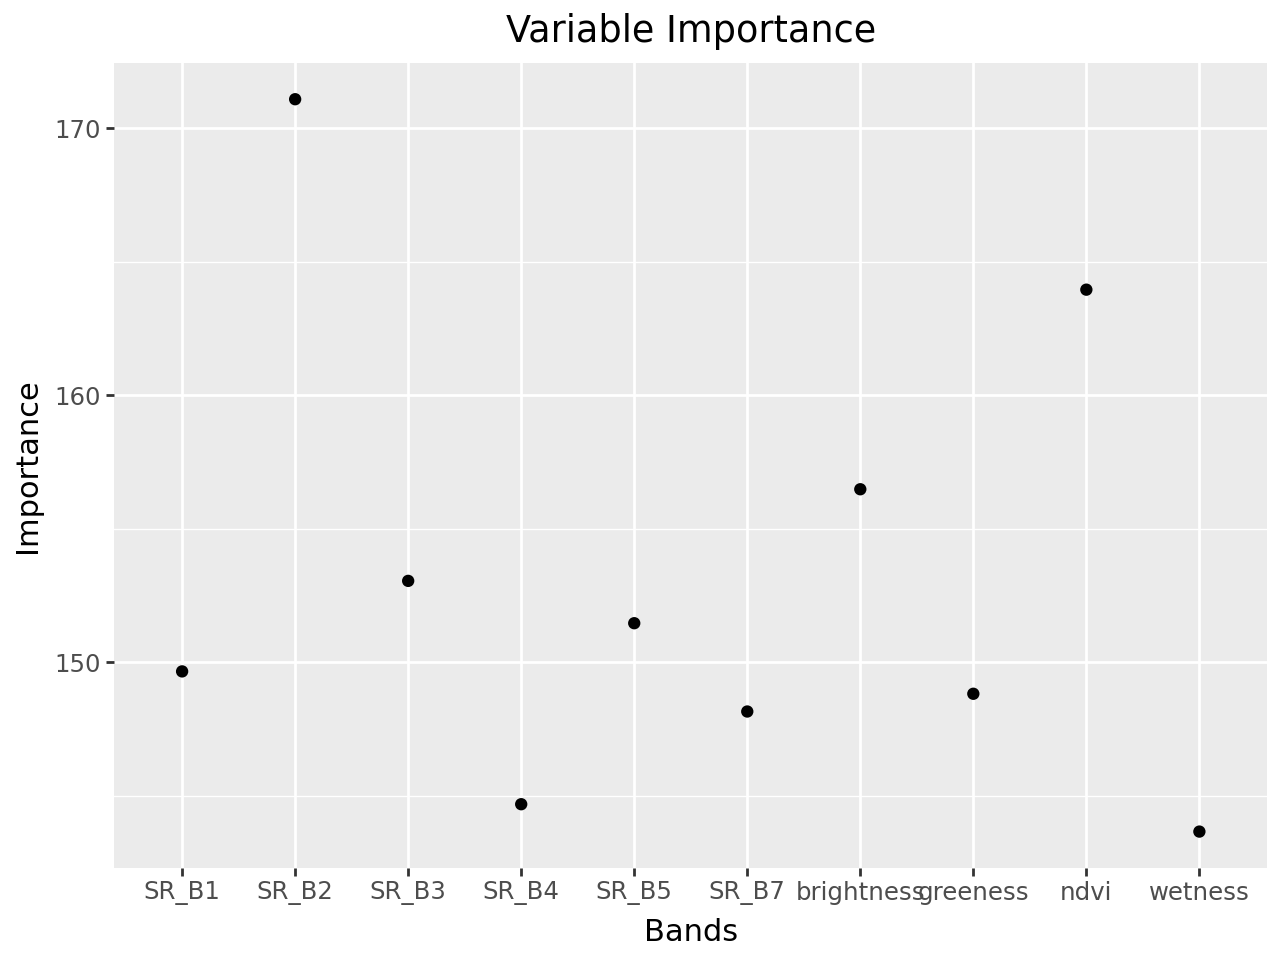

In [19]:
# Create a ggplot point plot with bands on the x and values on the y
(
    ggplot(importance_df, aes(x=bands, y=values))
    + geom_point()
    + labs(title= 'Variable Importance', x="Bands",y="Importance")
)

Based on our variable importance results, we can see that B4 and TCT wetness are relatively unimportant to our decision tree. They aren't used very often to make distinctions between two classes at a node in the tree.

On the other hand, NDVI is very important and is used frequently to make distinctions between classes at nodes in the tree.


Let's check the accuracy of our initial classification scheme before we go on to transfer it.

In [20]:
##### Independent Validation Accuracy Assessment #####
# Get a confusion matrix (using the testing set)
confusionMatrix = ee.ConfusionMatrix(testingSet.classify(trained)
    .errorMatrix(**{
      'actual': 'ClassID',
      'predicted': 'classification'
    }))

print("confusion matrix", confusionMatrix.getInfo())
print("overall accuracy", confusionMatrix.accuracy().getInfo())
print("producer's accuracy", confusionMatrix.producersAccuracy().getInfo())
print("consumer's accuracy", confusionMatrix.consumersAccuracy().getInfo())

confusion matrix [[0, 0, 0, 0], [0, 41, 5, 12], [0, 14, 15, 4], [0, 11, 3, 100]]
overall accuracy 0.7609756097560976
producer's accuracy [[0], [0.7068965517241379], [0.45454545454545453], [0.8771929824561403]]
consumer's accuracy [[0, 0.6212121212121212, 0.6521739130434783, 0.8620689655172413]]


The overall accuracy is moderate.  

Looking a bit closer at the confusion matrix we can see that Class 1 is frequently misclassified as Class 2 or 3.  

We can also see that Class 2 is somewhat poorly defined based on the misclassifications as both Class 1 and Class 3.

Class 3 seems to have been well defined and well classified with a few points being wrongly assigned.

The producer's accuracy is quite low for Class 2. Remember that producer's accuracy represents how many accidental omissions of each class occured AKA how many times a class was mistakenly not assigned to a pixel. We could see from the confusion matrix that this was the case, so this is expected.

# Temporal Transfer Learning

A classification scheme is trained for an AOI using an image acquired at a particular date and the classification is established to work well for that area. Then the same classification model is applied to the same AOI at another date, without any retraining.  

Temporal transfering works best when conditions are exactly the same between dates, however this isn't possible in the real world. The hope is that the distribution of the spectral information is similar because the location is the same so the classification scheme should still work even though some time has passed and conditions may not be exactly the same.

We have already trained the random forest classifier on our Landsat-5 1990 Alfred Bog image. Let's get another Landsat-5 image of the bog from 2010 and test out how the classification information transfers across time.




In [21]:
# Create a point feature for our AOI (Alfred Bog)
point = ee.Geometry.Point([-74.8588,45.4839])

# Filter for images within our date range that overlap our point
# Sort by cloud cover and choose least cloudy (first)
l5SR_Summer2010 = l5SR.filterBounds(point) \
                      .filterDate('2010-06-01', '2010-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .qualityMosaic ('ndvi') \
                      .float()

In [22]:
# Let's check out both of our cloud masked images on a map
Map = geemap.Map()


Map.addLayer(l5SR_Summer1990, l5visparams,'l5SR_Summer1990')
Map.addLayer(l5SR_Summer2010, l5visparams,'l5SR_Summer2010')
Map.addLayer(point, {}, 'Alfred Bog')

Map.addLayerControl()
Map.centerObject(point,8)

Map

Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

Zoom into Alfred Bog and compare the two image. Do the images make it appear that the conditions were the same for the two time periods?  Remember to experiment with different colour stretches to maximize variability across the landscape, but make sure to use the same colour stretch between images.  

## Estimate Temporal Transfer Success

We're going to do a bit of a test to estimate the success of our temporal transfer.

With transfer learning the conditions have to be very similar for it to work well.

We'll extract samples from the new image (2010) at the same locations as our original training data set using our Alfred training points.

Then we'll visualize the histograms for Brightness from both dataframes and compare them. This should show us if the training point locations have relatively similar spectral information in Brightness in both images.


If they're close to the same (mean, variance, skewness) then our transfer might be successful! Of course we would have to check out all the bands to know this for sure so this is just a taste.

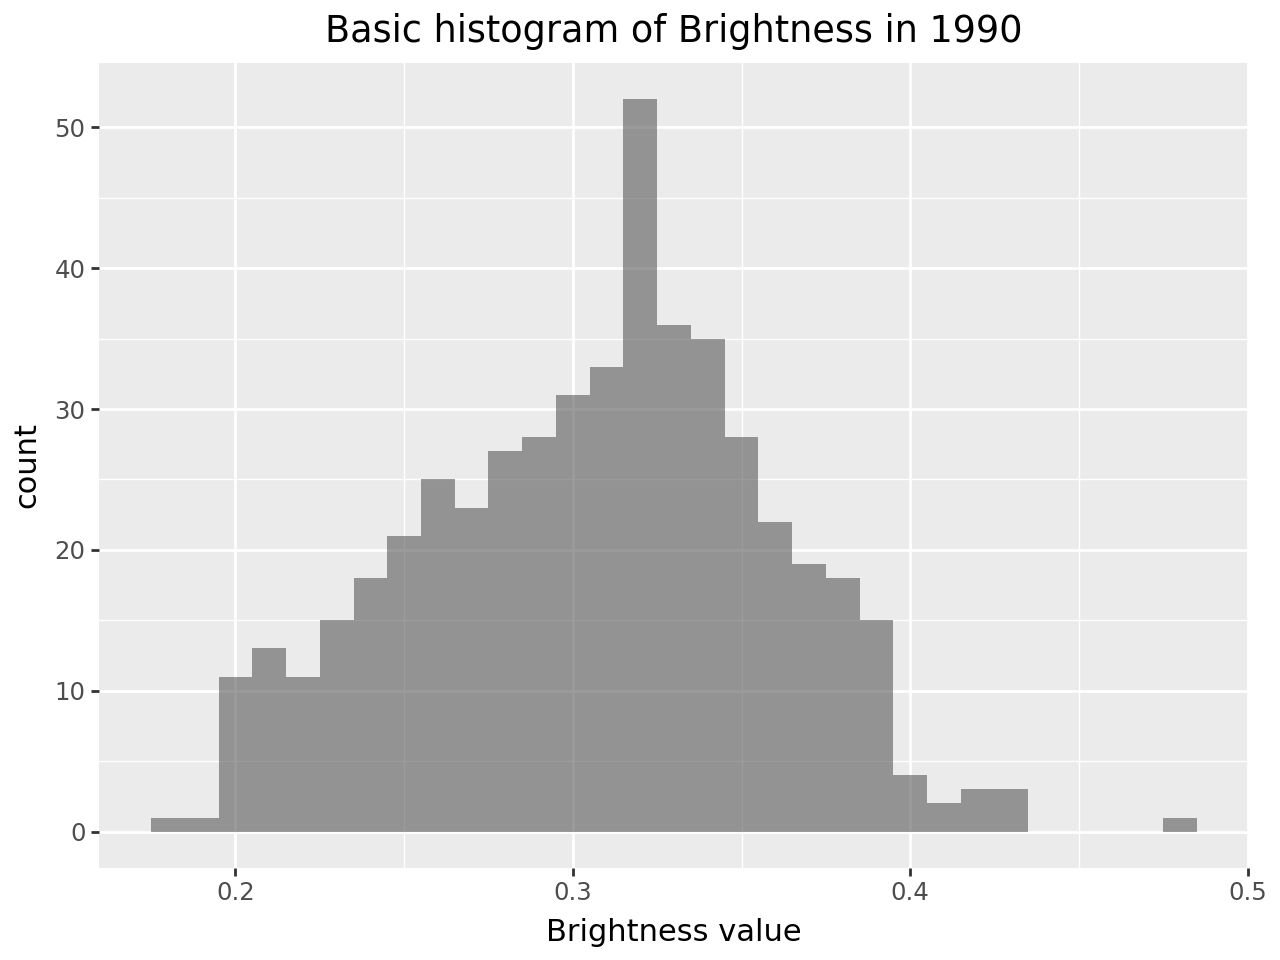

In [23]:
# Let's take a look at Brightness in our training data
(
ggplot(df, aes(x = "brightness"))
+ geom_histogram(alpha=0.6, binwidth = 0.01)
+ labs(title="Basic histogram of Brightness in 1990",
        x ="Brightness value", y = "count")
)

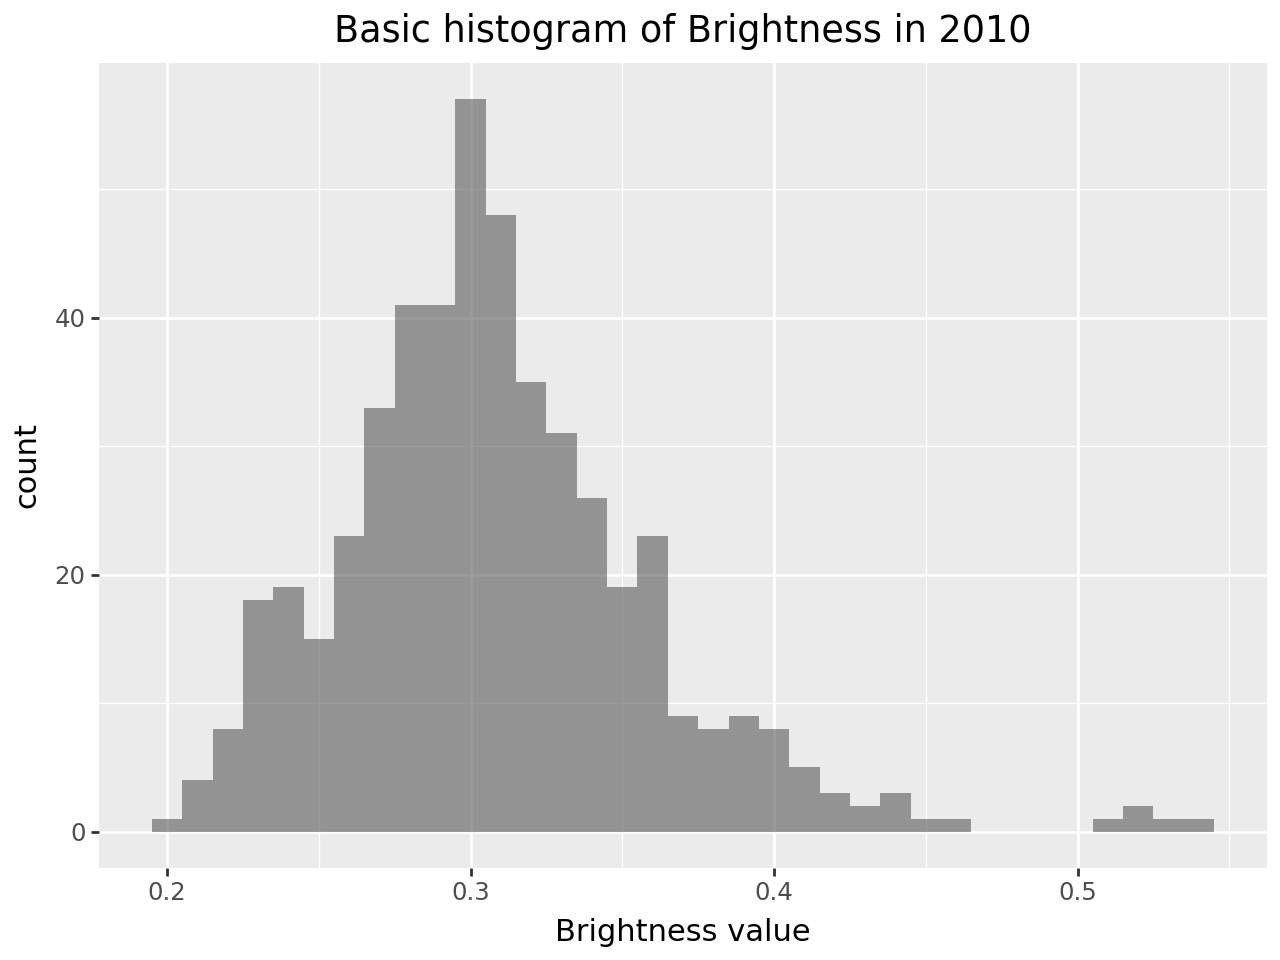

In [24]:
# Extract training data from the 2010 image
temporal = l5SR_Summer2010.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)

# To take a look at our training data we will convert the ee FeatureCollection into a pandas data frame


# Plot the histogram of Brightness
(
ggplot(df2, aes(x = "brightness"))
+ geom_histogram(alpha=0.6, binwidth = 0.01)
+ labs(title="Basic histogram of Brightness in 2010",
        x ="Brightness value", y = "count")
)

These histograms look similar, but not exactly the same.  There are a few more outliers in the upper range of our 2010 image so the distribution is positively skewed and the means will be different. This might affect our temporal transfer's success but we won't know until we assess our classification results.

In [25]:
# Create our classified temporal transfer image
classified_temporal = l5SR_Summer2010.select(bands).classify(trained)

In [26]:
Map = geemap.Map()

# Add our images
Map.addLayer(l5SR_Summer1990, l5visparams,'l5SR_Summer1990')
Map.addLayer(l5SR_Summer2010, l5visparams,'l5SR_Summer2010')

# Add our classifed results to the map
# We have 3 classes so need 3 colours in our pallette
# Use the same visparams for both classifications so they are easy to compare
  # Wetland - Blue
  # Agriculture - Yellow
  # Forest - Green
palette = ['D6E51B', '288857', '461BE5']
class_visparams = {
  'min': 1,
  'max': 3,
  'palette': palette}

Map.addLayer(classified, class_visparams, 'Classified Result 1990')
Map.addLayer(classified_temporal, class_visparams, 'Classified Result 2010')

Map.addLayer(point, {}, 'Alfred Bog')

Map.addLayerControl()
Map.centerObject(point,8)

Map

Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

Compare the two classifications by turning the layers on and off. Focus on the area around Alfred Bog - the entire image was classified but since the training data was focused on the bog, the areas further away from the bog may represent classes that are not in our training data.  

It seems like the middle of the bog was misclassified in the 2010 image. My guess is that 2010 was a dryer year, so the Wetland was mistakenly classified as Agriculture due to the wetness values being lower than the trained classifier expects. We have smaller water bodies throughout the image so this is a reasonable explanation for the discrepancies.

There is also more confusion between Forest and Agriculture. We would have to do more investigating to find out why this is happening, but we can see that Agriculture dominates areas initially classified as Forest and Wetland.

# Spatial Transfer Learning

Southern Ontario has a few other Bogs.  Mer Bleue was captured in the same images you used for Alfred Bog.  Take a look - how well was Mer Bleue captured in the resulting classifications?  In this case, we weren't even "transfering" our classification - but we can see that our training data for Alfred Bog was not representative of Mer Bleue.  


Based on this, we can already guess that there are very few bogs in Ontario that might look spectrally similar to Alfred Bog. For our spatial transfer,  we will try another area in southern Ontario that contains open and treed bog.  Luther Marsh and the Wylde Lake Conservation area (north of Guelph) contains both marsh (cat-tails, grasses), open bog (Sphagnum dominated like Alfred and Mer Bleue) and treed bog.  Both Alfred and Luther Marsh are surrounded by agriculture.  

Remember, to do either a spatial or temporal transfer, the conditions have to be very similar between images for a successful classification. We also need to work with areas of similar land cover with similar climates and sesonality.

In [27]:
# Define a point for Mer Bleue
LutherMarsh = ee.Geometry.Point([-80.423801, 43.922740, ])

# Filter for images within our date range that overlap our point
# Sort by cloud cover and choose least cloudy (first)
l5SR_LutherMarsh = l5SR.filterBounds(LutherMarsh).filterDate('1990-06-01', '1990-08-31').filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .qualityMosaic ('ndvi') \
                      .float()


Map = geemap.Map()

# Add both of our images to the map so we can compare Alfred Bog and Mer Bleue bog in both images
Map.addLayer(l5SR_Summer1990, l5visparams,'l5SR_Alfred1990')
Map.addLayer(l5SR_LutherMarsh, l5visparams, 'l5SR_LutherMarsh1990')
Map.addLayer(LutherMarsh, {}, 'Luther Marsh Bog')

Map.center_object(LutherMarsh, 10)

Map

Map(center=[43.92274, -80.423801], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

Alfred Bog isn't covered by this image so we can't compare what the training data from this image would look like compared to the original image training data.

If we could, we could see if there are differences in overall brightness, greenness, NDVI, and wetness values to see if the image in general has spectral differences. There shouldn't be major physical changes between the two images because they were taken at roughly the same time, so differences in spectral information would be due to differences in calibration etc.

Interpreting visually, there seems to be a slight difference in overall brightness between the images.

In [28]:
# Create our classified spatial transfer image
classified_spatial = l5SR_LutherMarsh.select(bands).classify(trained)

In [29]:
Map = geemap.Map()


# Add our images
Map.addLayer(l5SR_Summer1990, l5visparams,'l5SR_Alfred1990')
Map.addLayer(l5SR_LutherMarsh, l5visparams,'l5SR_LutherMarsh1990')

# Add our classifed result to the map
# We have 3 classes so need 3 colours in our pallette
  # Wetland - Blue
  # Agriculture - Yellow
  # Forest - Green
palette = ['D6E51B', '288857', '461BE5']
class_visparams = {
  'min': 1,
  'max': 3,
  'palette': palette}

Map.addLayer(classified, class_visparams, 'Classified Result Alfred 1990')
Map.addLayer(classified_spatial, class_visparams, 'Classified Result Luther Marsh 1990')

Map.addLayer(point, {}, 'Alfred Bog')
Map.addLayer(LutherMarsh, {}, 'Luther Marsh')

Map.addLayerControl()
Map.centerObject(point,8)

Map

Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

# Questions

## Q1

Looking at the spatial transfer results to Luther Marsh, and even if you zoom out while looking at the original Alfred results, it is clear that there is one big problem with these classifications: there is no open water class, so all open water gets "mapped" as "wetland".

Using any imagery you choose (i.e. basemaps, Planet or the Landsat data), create training data for Luther Marsh that includes the following classes:

- wetland (all classes combined)
- upland forest
- open water
- agriculture

(if you happen to see other classes that you want to collect, feel free).

Use this training data to classify Luther Marsh again and provide an interpretation of the quality of the results.  

// Your interpretation here:

In [39]:
#Create shapefile from landsat imagery
# Import the Landsat-8 Tier 1 Surface Reflectance collection as a variable
l8SR = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

#Applies scaling factors
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )

# We're omitting B6 from our functions because for Landsat 5 TM Band 6 is thermal.
def tCapB(image):
  Brightness = image.expression(
      '((0.3029*B1)+(0.2786*B2)+(0.4733*B3)+(0.5599*B4)+(0.508*B5)+(0.1872*B7))',{
          'B1': image.select ('SR_B1').float(),
          'B2': image.select ('SR_B2').float(),
          'B3': image.select ('SR_B3').float(),
          'B4': image.select ('SR_B4').float(),
          'B5': image.select ('SR_B5').float(),
          'B7': image.select ('SR_B7').float(),
          }).rename('brightness');
  return image.addBands(Brightness);

def tCapG(image):
  Greeness = image.expression(
      '((-0.2941*B1)-(0.243*B2)-(0.5424*B3)+(0.7276*B4)+(0.0713 * B5)-(0.1608 * B7))',{
          'B1': image.select ('SR_B1').float(),
          'B2': image.select ('SR_B2').float(),
          'B3': image.select ('SR_B3').float(),
          'B4': image.select ('SR_B4').float(),
          'B5': image.select ('SR_B5').float(),
          'B7': image.select ('SR_B7').float(),
          }).rename('greeness');
  return image.addBands(Greeness);

def tCapW(image):
  Wetness = image.expression(
      '((0.1511*B1)+(0.1973*B2)+(0.3283*B3)+(0.3407*B4)-(0.7117 * B5)-(0.4559 * B7))',{
          'B1': image.select ('SR_B1').float(),
          'B2': image.select ('SR_B2').float(),
          'B3': image.select ('SR_B3').float(),
          'B4': image.select ('SR_B4').float(),
          'B5': image.select ('SR_B5').float(),
          'B7': image.select ('SR_B7').float(),
          }).rename('wetness');
  return image.addBands(Wetness);

# Create a point feature for Luther
point = ee.Geometry.Point([-80.43, 43.94])

# Filter our image collection for images in our date range that cover our point
# Then sort by cloud cover and select the least cloudy using the .first() function
l8SR_2020_LC =  l8SR.filterBounds(point) \
                      .filterDate('2020-06-01', '2020-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .sort("CLOUD_COVER") \
                      .first()


In [40]:
l8visparams = {
       'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
       'min': 0,
       'max': 0.3}
# Filter for images within our date range that overlap our point
Map = geemap.Map()

#add Luther imagery \\
Map.addLayer(l8SR_2020_LC, l8visparams, 'l8sr_luthermarshMeadows 2020')
Map.center_object(point, 10)

Map

Map(center=[43.94, -80.43], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

In [32]:
#Generate sample points in qgis for 4 classes. Basemap is Google Satellite and OpenStreetMaps (supplemented with CFS forest fuels layer).

In [88]:
luthertrain = 'C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2/data/lutherbog_training3.shp'

# Convert the shapefile (.shp) to an EE feature
shpdata = geemap.shp_to_ee(luthertrain)
shpdata
df = geemap.ee_to_df(shpdata)

# We are going to define a variable to specify the bands we will use for prediction
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'brightness', 'greeness', 'wetness', 'ndvi']

# This variable defines the property of our training data table which stores the land cover labels
label = 'Class'

# Create our training data by extracting pixel values for each training data point
trainingLuther = l8SR_2020_LC.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)
# To take a look at our training data we will convert the ee FeatureCollection into a pandas data frame
df = geemap.ee_to_df(trainingLuther)
df.head() # The head function displays the first few records of a data frame

,Class,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,SR_B7,brightness,greeness,ndvi,wetness
0,3,0.082535,0.098155,0.141688,0.169820,0.306358,0.363447,0.438156,-0.038015,0.090311,-0.247520
1,3,0.067713,0.078630,0.118450,0.133493,0.334243,0.287300,0.396799,-0.028506,0.059706,-0.258747
2,3,0.027232,0.029020,0.053082,0.030532,0.467343,0.068868,0.308855,0.000610,-0.269688,-0.326334
3,3,0.025583,0.027562,0.051432,0.028553,0.472650,0.066613,0.308333,0.001645,-0.286054,-0.330837
4,3,0.035208,0.036747,0.070022,0.047198,0.509885,0.114875,0.360996,-0.005041,-0.194719,-0.363618


In [65]:
#Here is the classifier
trainingTestingLuther = trainingLuther.randomColumn()
trainingSetLuther = trainingTestingLuther.filter(ee.Filter.lessThan('random', 0.6))
testingSetLuther = trainingTestingLuther.filter(ee.Filter.greaterThanOrEquals('random',0.6))

# Train a Random Forest classifier with 250 trees
luther2020Model = ee.Classifier.smileRandomForest(250).train(trainingSetLuther,label,bands)
classified_temporal = l8SR_2020_LC.select(bands).classify(luther2020Model)

# this is a dictionary that stores the variable importance values from the smileRF classifier
explained = luther2020Model.explain()

###IMPORTANT CHANGES TO LAB

# Extract the importance of variables from the explanation
importance = ee.Dictionary(explained.get('importance'))

# Print the importance scores of each variable
print('Variable Importance:', importance.getInfo())
Map = geemap.Map()
##########################################################

# # Add our images
# Map.addLayer(l5SR_Summer1990, l5visparams,'l5SR_Summer1990')
# Map.addLayer(l5SR_Summer2010, l5visparams,'l5SR_Summer2010')

# Add our classifed results to the map
# We have 3 classes so need 3 colours in our pallette
# Use the same visparams for both classifications so they are easy to compare
    # 1 Wetland - Purple ab1be5
    # 2 Forest - Green 288857
    # 3 Agriculture - Orange e5ab1b
    # 4 Water - Blue 461BE5

palette = ['ab1be5', '288857',  'e5ab1b', '461BE5']
class_visparams_luther = {
  'min': 1,
  'max': 4,
  'palette': palette}

Map.addLayer(classified_temporal, class_visparams, 'Classified Result 2020')
Map.addLayer(l8SR_2020_LC, l8visparams, 'l8sr_luthermarshMeadows 2020')
Map.addLayer(point, {}, 'Alfred Bog')

Map.addLayerControl()
Map.centerObject(point,11)

Map

Variable Importance: {'SR_B1': 85.13166331020379, 'SR_B2': 82.04959267236946, 'SR_B3': 90.18043520939187, 'SR_B4': 72.9697443601876, 'SR_B5': 95.17166754620499, 'SR_B7': 100.18049795342114, 'brightness': 116.33519162896766, 'greeness': 88.0431129357426, 'ndvi': 82.93691995456626, 'wetness': 94.18179183717952}


Map(center=[43.94, -80.43], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

The classification is alright, but has several substantial shortcomings. It seems to have done an alright job at classifying the open water, which is quite spectrally distinct from the other land cover classes. The boundary between wetland and forest classes is not well-defined, and neither is the boundary between agricultural and forest classes. It seems that the model overclassifies agricultural space, erroneously calling several areas agriculture which were probably forest.

It's unclear if these errors arise from misclassiifications in the training data (unlikely), or spectrally similar classes (more likely). It would be valuable to try a different season when there may be a greater distinction between agricultural areas and forest/wetland areas. Maybe late fall.

## Q2:

Now use the new model created from the Luther Marsh training data to create a transfered classification at Alfred.  

How well did this work?  Provide an interpretation of the quality of the results.

In [70]:
pointAlfred = ee.Geometry.Point([-74.8588,45.4839])

# Then sort by cloud cover and select the least cloudy using the .first() function
l8SR_2020_Alfred =  l8SR.filterBounds(pointAlfred) \
                      .filterDate('2020-06-01', '2020-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .sort("CLOUD_COVER") \
                      .first()

classified_lutherToAlfred2020 = l8SR_2020_Alfred.select(bands).classify(luther2020Model)
MapAlfred2020 = geemap.Map()
MapAlfred2020.addLayer(l8SR_2020_Alfred, l8visparams, 'Alfred Bog SR')
MapAlfred2020.addLayer(classified_lutherToAlfred2020, class_visparams, 'Temporal Classification Luther>>Alfred 2020')
MapAlfred2020.addLayer(pointAlfred, {}, 'Alfred Bog')

MapAlfred2020.addLayerControl()
MapAlfred2020.centerObject(pointAlfred,11)

MapAlfred2020

Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

// Your interpretation here

The temporal classification does an alright job of defining the boundary between forest and wetland, and in drawing the limits of the forest class. It identifies no surface water, which is probably accurate at this resolution. Unfortunately it has a very high false positive rate on wetland, classifying many of the surrounding agricultural fields as wetland.

##Q2b

Add new training data to capture the "open water" class to the original Alfred data.  Re-run the classification and compare to the original results, and the transfered classification from Luther Marsh.  

Provide an comparison of the results.  

In [77]:
gdf = geopandas .read_file( 'C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2/TrainingDataAlfred/training_dataAlfred.shp')

# Display the first few rows of the attribute table
print(gdf.head())

   ClassID    ClassName                    geometry
0        1  Agriculture  POINT (-74.83808 45.52434)
1        1  Agriculture  POINT (-74.87626 45.46144)
2        1  Agriculture  POINT (-74.87468 45.45723)
3        1  Agriculture  POINT (-74.83864 45.51361)
4        1  Agriculture  POINT (-74.82853 45.53454)


In [95]:
AlfredPts = 'C:/Users/cptci/Documents/GitHub\GEOG6006-qb_v2/TrainingDataAlfred/training_dataAlfred_v2.shp'
shpdata = geemap.shp_to_ee(AlfredPts)
label = 'ClassID'   

In [108]:
AlfredPts = 'C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2/TrainingDataAlfred/training_dataAlfred_v3.shp'
shpdata = geemap.shp_to_ee(AlfredPts)
label = 'ClassID'    ###########################NOTE NOTE NOTE will ClassID being 'Class' only in the other dataset affect the later parts of this code?


# Then sort by cloud cover and select the least cloudy using the .first() function
l8SR_2020_Alfred =  l8SR.filterBounds(pointAlfred) \
                      .filterDate('2020-06-01', '2020-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .sort("CLOUD_COVER") \
                      .first()

# Create our training data by extracting pixel values for each training data point
trainingAlfred2020 = l8SR_2020_Alfred.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)

trainingTestingAlfred2020 = trainingAlfred2020.randomColumn()
trainingSetAlfred2020 = trainingTestingAlfred2020.filter(ee.Filter.lessThan('random', 0.6))
testingSetAlfred2020 = trainingTestingAlfred2020.filter(ee.Filter.greaterThanOrEquals('random',0.6))

# Train a Random Forest classifier with 250 trees
alfred2020Model = ee.Classifier.smileRandomForest(250).train(trainingSetAlfred2020,label,bands)
classified2020Alfred = l8SR_2020_Alfred.select(bands).classify(alfred2020Model)

# Use the same visparams for both classifications so they are easy to compare
#In an ideal world we'd have the same classification scheme between training points. Oh well.
    # 1 Agriculture e5ab1b yellow
    # 2 Forest - Green 288857
    # 3  #Wetland - Purple ab1be5
    # 4 Water - Blue 461BE5



palette = ['e5ab1b', '288857',  'ab1be5', '461BE5']
class_visparams_alfred = {
  'min': 1,
  'max': 4,
  'palette': palette}

MapAlfred2020 = geemap.Map()
MapAlfred2020.addLayer(l8SR_2020_Alfred, l8visparams, 'Alfred Bog SR')
MapAlfred2020.addLayer(classified2020Alfred, class_visparams_alfred, 'Classification Alfred 2020')
MapAlfred2020.addLayer(pointAlfred, {}, 'Alfred Bog')

MapAlfred2020.addLayerControl()
MapAlfred2020.centerObject(pointAlfred,11)

MapAlfred2020


Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

\\ Your interpretation here
Much better. Still almost no surface water in Alfred, but the nearby tributaries are correctly classified.

## Q3

Create an intermediate temporal classification for Alfred Bog in the Summer of 2000 using the classification scheme we tried on our initial image of Alfred Bog from 1990.

Put all three of our temporal classifications and their source images on the map: Alfred 1990, Alfred 2000 (your classification), and Alfred 2010.

Interpret your classification and the big differences between the classifications in the series in a few sentences.

Hint: check out the south-western corner of the bog where peat mining operations have been ongoing since the 1900s.

In [164]:
# Create the training data for your 2000 Alfred image
AlfredPts = 'C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2/TrainingDataAlfred/training_dataAlfred_v3.shp'
shpdata = geemap.shp_to_ee(AlfredPts)
label = 'ClassID'    ###########################NOTE NOTE NOTE will ClassID being 'Class' only in the other dataset affect the later parts of this code?



# Then sort by cloud cover and select the least cloudy using the .first() function
l5SR_2000_Alfred =  l5SR.filterBounds(pointAlfred) \
                      .filterDate('2000-06-01', '2000-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .sort("CLOUD_COVER") \
                      .first()

# Create our training data by extracting pixel values for each training data point
trainingAlfred2000 = l5SR_2000_Alfred.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)

trainingTestingAlfred2000 = trainingAlfred2000.randomColumn()
trainingSetAlfred2000 = trainingTestingAlfred2000.filter(ee.Filter.lessThan('random', 0.6))
testingSetAlfred2000 = trainingTestingAlfred2000.filter(ee.Filter.greaterThanOrEquals('random',0.6))

# Train a Random Forest classifier with 250 trees
alfred2000Model = ee.Classifier.smileRandomForest(250).train(trainingSetAlfred2000,label,bands)
classified2000Alfred = l5SR_2000_Alfred.select(bands).classify(alfred2000Model)

# Use the same visparams for both classifications so they are easy to compare
#In an ideal world we'd have the same classification scheme between training points. Oh well.
    # 1 Agriculture e5ab1b yellow
    # 2 Forest - Green 288857
    # 3  #Wetland - Purple ab1be5
    # 4 Water - Blue 461BE5

palette = ['e5ab1b', '288857',  'ab1be5', '461BE5']
class_visparams_alfred = {
  'min': 1,
  'max': 4,
  'palette': palette}

l5visparams = {
       'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
       'min': 0,
       'max': 0.3,
       'gamma': [0.95, 1.1, 1]
     }

Map = geemap.Map()
Map.addLayer(l5SR_2000_Alfred, l5visparams, 'Alfred Bog SR')
Map.addLayer(classified1990Alfred, class_visparams_alfred, 'Classification Alfred 1990')
Map.addLayer(classified2000Alfred, class_visparams_alfred, 'Classification Alfred 2000')
Map.addLayer(classified2020Alfred, class_visparams_alfred, 'Classification Alfred 2020')

Map.addLayer(pointAlfred, {}, 'Alfred Bog')

Map.addLayerControl()
Map.centerObject(pointAlfred,11)

Map

Map(center=[45.4839, -74.8588], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchD…

The peatland area is shrinking, with a crisp and clear boundary between agriculture and peatland appearing between 1990 and 2000. This appears to continue through to 2020, but the difference is less substantial than the 1990>2000 change.

  Class   Pixel_Count
0     1  72584.168627
1     2  13930.313725
2     3   7829.074510
3     4   5652.282353
  Class   Pixel_Count
0     1  69728.886275
1     2  19250.415686
2     3   5461.172549
3     4   5558.549020
  Class   Pixel_Count
0     1  70740.035294
1     2  13226.290196
2     3  10879.254902
3     4   5152.407843


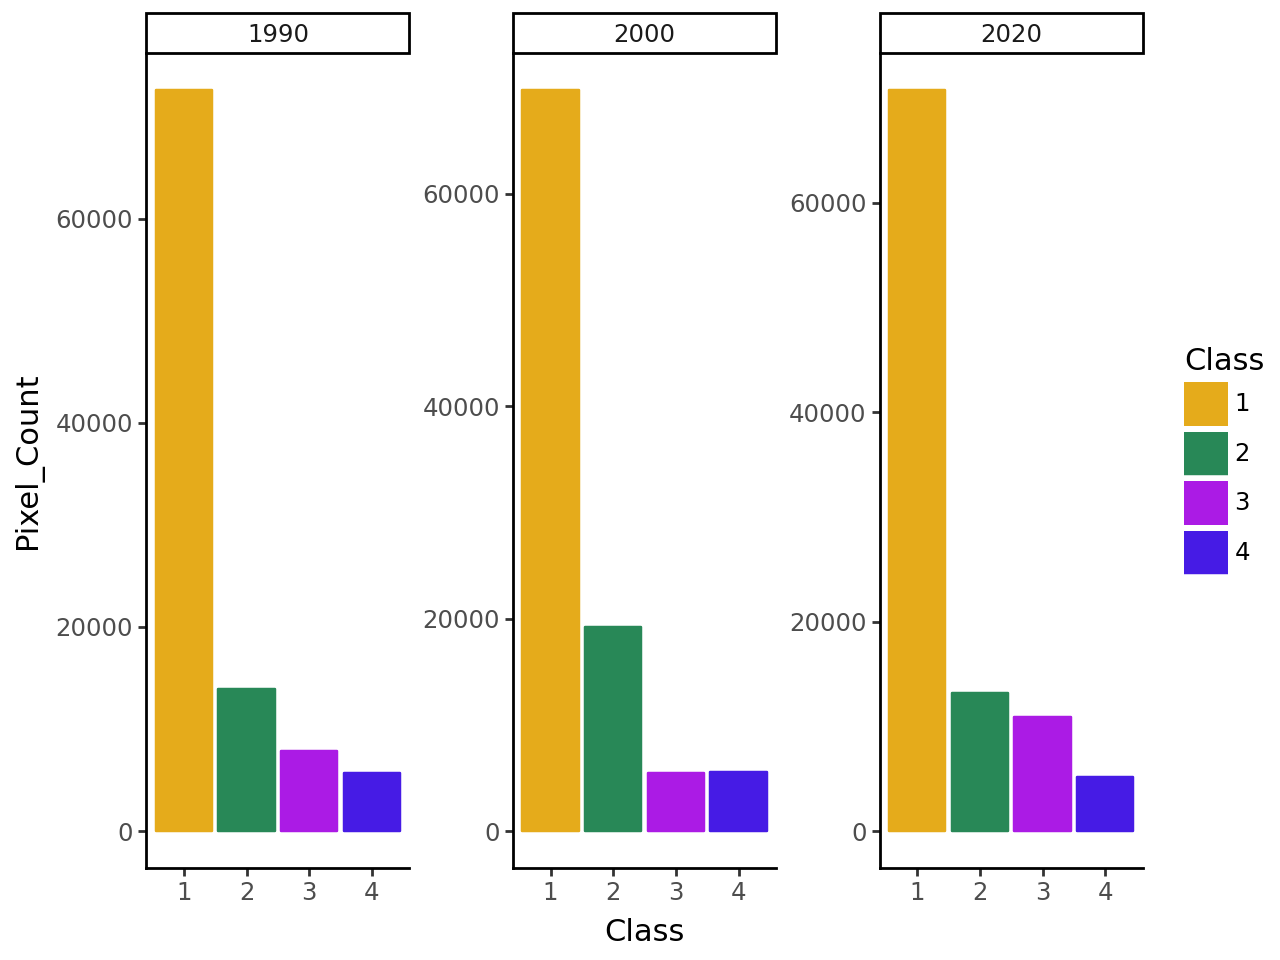

In [177]:
#Get the data as a usable data frame
sampleRegion = ee.Geometry.Polygon([[-75.08409,45.62605],
                                     [-74.78093,45.62749],
                                     [-74.77716,45.50659],
                                     [-75.0858,45.50864]])

pixel_counts = classified1990Alfred.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=sampleRegion,
    scale=30,  # Resolution in meters (change based on your dataset)
    maxPixels=1e5,
    bestEffort=True)

# Get the result as a dictionary
counts_dict = pixel_counts.getInfo()
histogram = counts_dict['classification']
df1990 = pd.DataFrame(list(histogram.items()), columns=['Class', 'Pixel_Count'])
print(df1990)
df1990['Year'] = 1990

#2000
pixel_counts = classified2000Alfred.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=sampleRegion,
    scale=30,  # Resolution in meters (change based on your dataset)
    maxPixels=1e5,
    bestEffort=True)
# Get the result as a dictionary
counts_dict = pixel_counts.getInfo()
histogram = counts_dict['classification']
df2000 = pd.DataFrame(list(histogram.items()), columns=['Class', 'Pixel_Count'])
print(df2000)
df2000['Year'] = 2000

#2020
pixel_counts = classified2020Alfred.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=sampleRegion,
    scale=30,  # Resolution in meters (change based on your dataset)
    maxPixels=1e5,
    bestEffort=True)

# Get the result as a dictionary
counts_dict = pixel_counts.getInfo()
histogram = counts_dict['classification']
df2020 = pd.DataFrame(list(histogram.items()), columns=['Class', 'Pixel_Count'])
print(df2020)
df2020['Year'] = 2020

df_combined = pd.concat([df1990, df2000, df2020], ignore_index=True)

ggpalette= ['#E5AB1B', '#288857',  '#AB1BE5', '#461BE5']
plot = (
    ggplot(df_combined, aes(x='Class', y='Pixel_Count', color='Class', fill='Class')) +  # Define the aesthetics (x and y axis)
    geom_bar(stat="identity") + # Create a bar plot with the pixel count +
    theme_classic() +
    scale_color_manual(values=ggpalette) +
        scale_fill_manual(values=ggpalette) +
    facet_wrap('Year', nrow = 1, scales = "free_y")
)
plot

# Create a ggplot histogram
# ggplot(df1990, aes(str("Class"), "Pixel_Count",   fill='Class'))
#     + geom_col()

# print(histogram)



// Your interpretation here

My interpretation is that our classifiers are bad! We should be seeing a decrease in total wetland area but we see an increase through to the 2020s. The pattern seems more correct for the transition from 1990 to 2000, but the increase in forest cover is incredibly unlikely. It's likely that we need a better method for building classifiers than select points from a basemap.

## Q4

# Create a new quality mosaic for Alfred Bog for the year 2000.  

Extract pixel values for the Alfred training points from your new image (I am assuming this means the LandSat imagery and derived bands, not the classificaiton image). Convert the training data into a dataframe as we did above.  Visualize histograms for relevant bands for both classifications and compare.

Write a few sentences comparing them visually. Based on the interpretation of the similarity in the two images, how successful would a transfer be?

>>>Okay, I may have misinterpreted the last question, but its hard to tell. If this is going to be marked, make sure you redo it.

In [180]:
# Your code here
# Create the training data for your 2000 Alfred image
AlfredPts = 'C:/Users/cptci/Documents/GitHub/GEOG6006-qb_v2/TrainingDataAlfred/training_dataAlfred_v3.shp'
shpdata = geemap.shp_to_ee(AlfredPts)
label = 'ClassID'    ###########################NOTE NOTE NOTE will ClassID being 'Class' only in the other dataset affect the later parts of this code?

# Then sort by cloud cover and select the least cloudy using the .first() function
l5SR_2000_Alfred =  l5SR.filterBounds(pointAlfred) \
                      .filterDate('2000-06-01', '2000-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .sort("CLOUD_COVER") \
                      .first()

# Create our training data by extracting pixel values for each training data point
trainingAlfred2000 = l5SR_2000_Alfred.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)

# Then sort by cloud cover and select the least cloudy using the .first() function
l5SR_2010_Alfred =  l5SR.filterBounds(pointAlfred) \
                      .filterDate('2010-06-01', '2010-08-31') \
                      .filterMetadata('CLOUD_COVER','less_than',20) \
                      .map(apply_scale_factors) \
                      .map(cloudMaskL5) \
                      .map(addQualityBands) \
                      .map(tCapB)\
                      .map(tCapG)\
                      .map(tCapW)\
                      .sort("CLOUD_COVER") \
                      .first()

# Create our training data by extracting pixel values for each training data point
trainingAlfred2010 = l5SR_2010_Alfred.select(bands).sampleRegions(
    collection = shpdata,
    properties = [label],
    scale = 30
)


NameError: name 'color_dict' is not defined

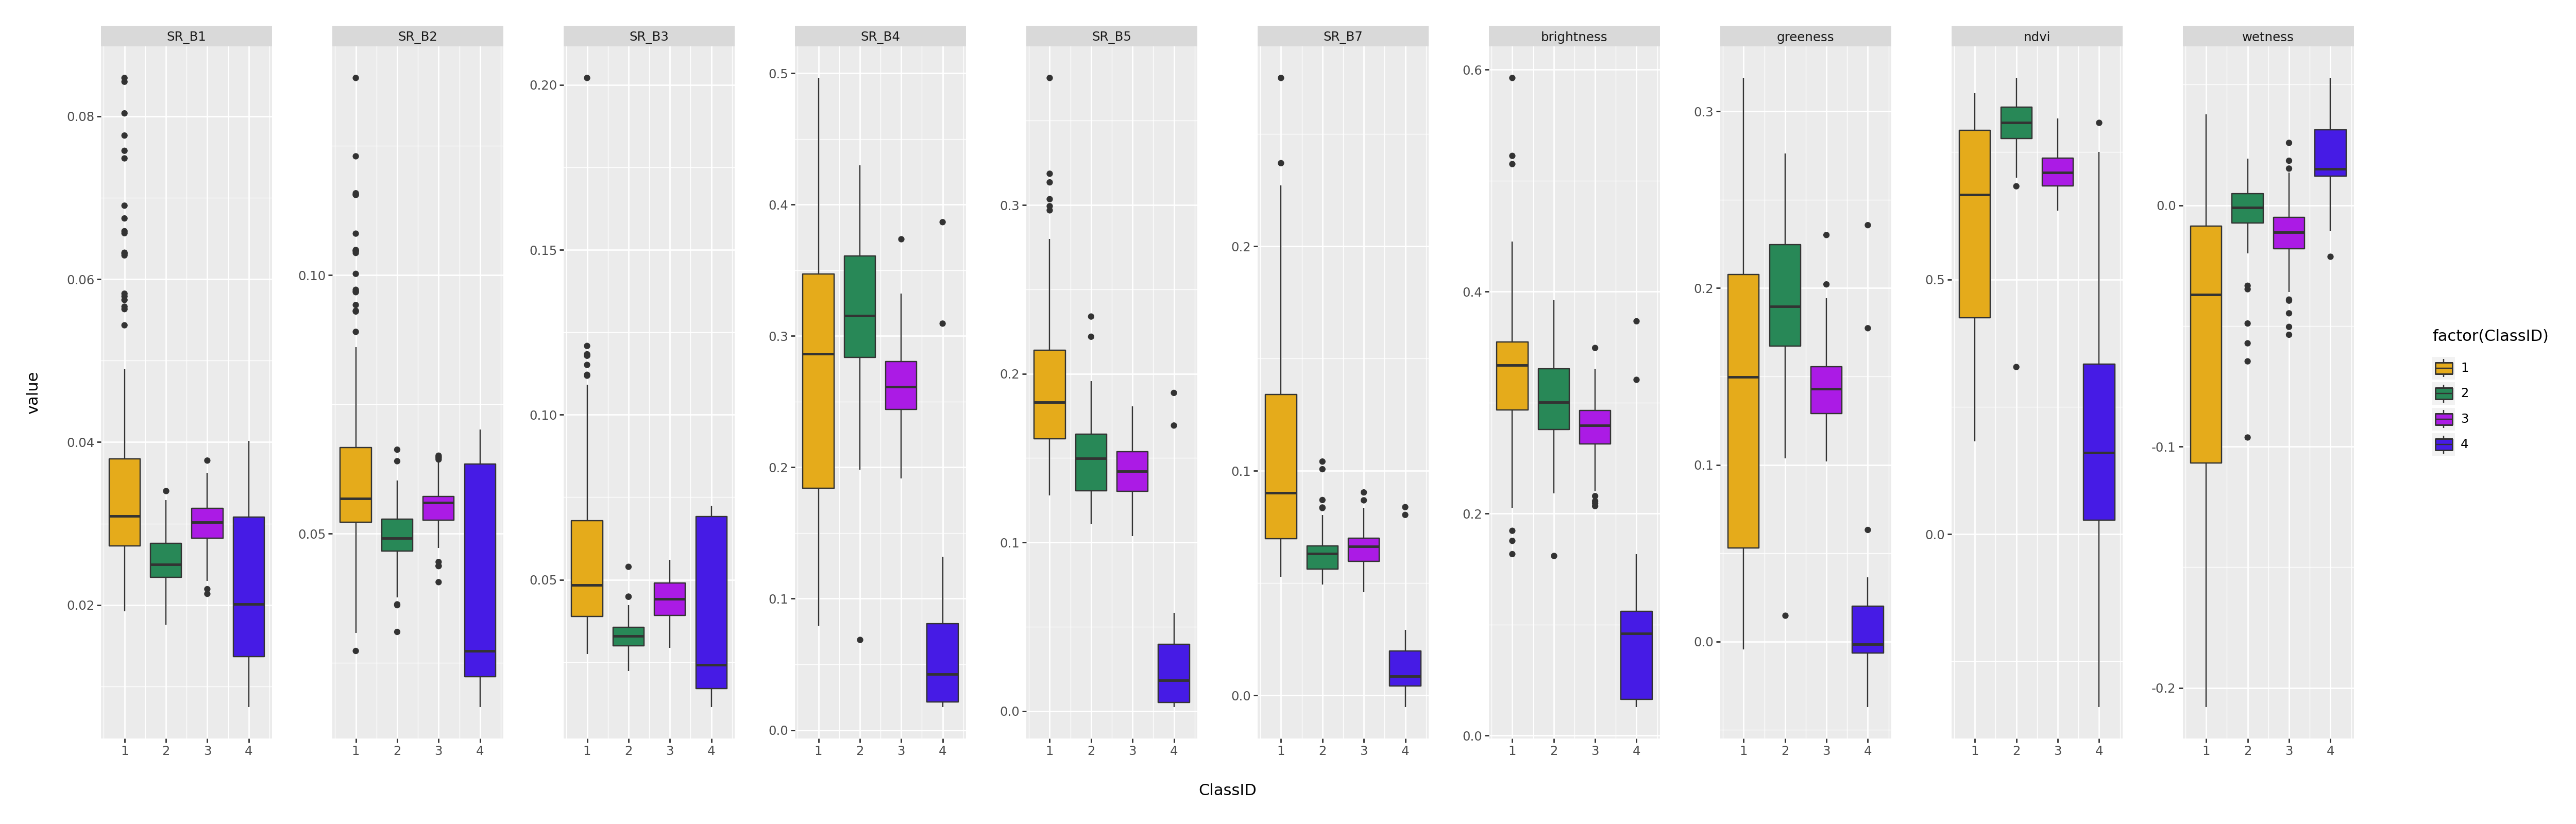

In [185]:

df2000 = geemap.ee_to_df(trainingAlfred2000)
df2010 = geemap.ee_to_df(trainingAlfred2010)

df2000 = df2000.melt(id_vars=['ClassID'], value_vars=['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'brightness', 'greeness', 'wetness', 'ndvi']) 
df2010 = df2010.melt(id_vars=['ClassID'], value_vars=['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'brightness', 'greeness', 'wetness', 'ndvi']) 

ggpalette= ['#E5AB1B', '#288857',  '#AB1BE5', '#461BE5']
(
    ggplot(df2000, aes(str("ClassID"), "value",   fill='factor(ClassID)'))
    + geom_boxplot()
    + facet_wrap("variable",  nrow = 1, scales = "free_y")
    + scale_fill_manual(ggpalette)
    + theme(figure_size=(25, 8), subplots_adjust={'wspace': 0.25})
)

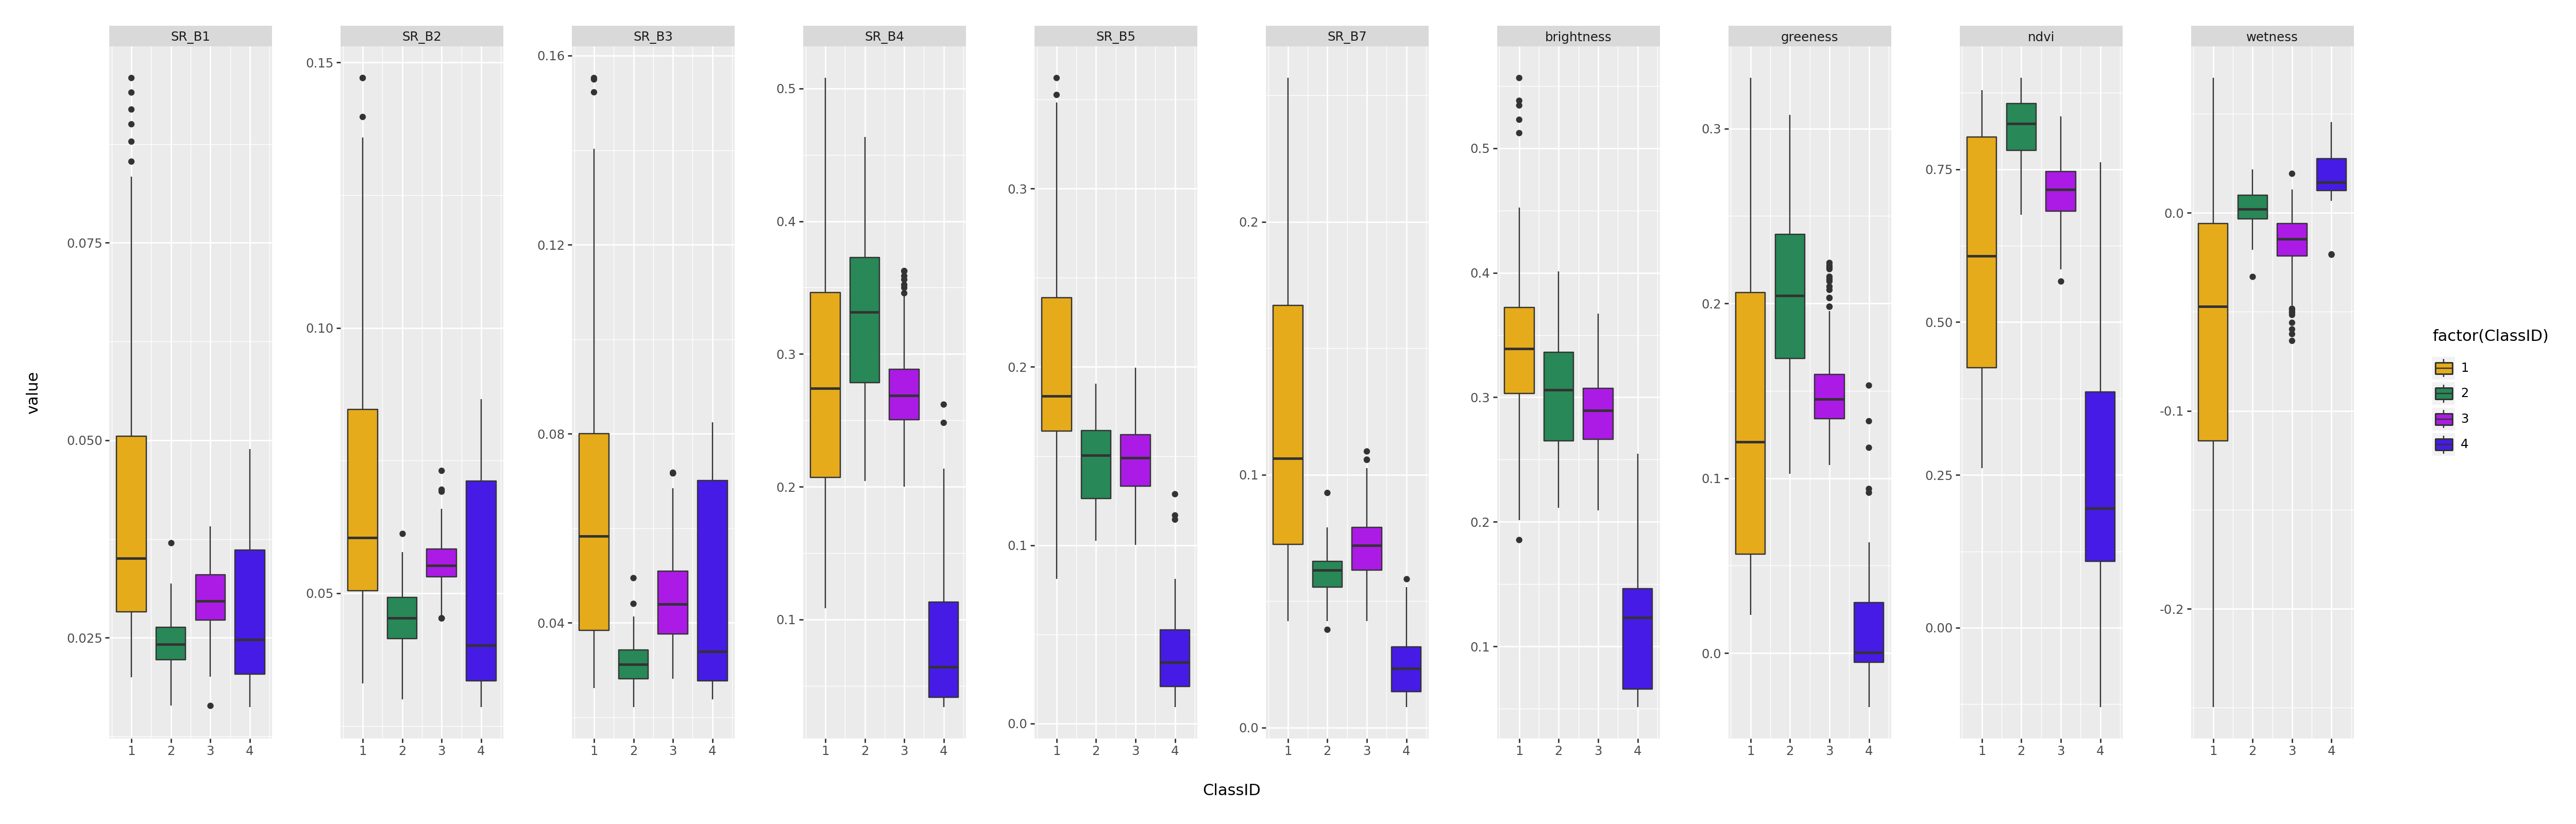

In [186]:

(
    ggplot(df2010, aes(str("ClassID"), "value",   fill='factor(ClassID)'))
    + geom_boxplot()
    + facet_wrap("variable",  nrow = 1, scales = "free_y")
        + scale_fill_manual(ggpalette)
    + theme(figure_size=(25, 8), subplots_adjust={'wspace': 0.25})
)

// Your interpretation here
It's a bit of a guessing game by looking at the boxplots, but it looks like the shape of the spectral response is nearly the same across the forest, wetland, and water classes. The agriculture response is quite a big wider (more variable) in the 2010 image, maybe because of collection at a different time of year or different crops being planted? I would guess that a transfer would be adequete but not better than that.